# Sensor Category Behaviour Audit (All Categories)

The wearable-only audit (`06_5`) found that 93% of "Wearable and Mobile Sensing"
articles were dominated by a competing near-miss category, mostly measuring
pedestrian behaviour rather than a built-environment attribute. That audit's
comparison against the `06.2` sensor-assignment threshold used an inconsistent
scoring method (whole-text embedding instead of the sentence-segmented, max-pooled
scoring `06.2` actually uses), so it could not properly test whether the assignment
threshold itself is too permissive.

This notebook fixes that (reusing `06.2`'s exact scoring function) and runs the same
near-miss audit across all six sensor categories at once, to check whether the
wearable contamination is an isolated case or a systemic pattern.

# 1. Setup

In [1]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import torch
from transformers import pipeline
from sentence_transformers import SentenceTransformer, util

pd.set_option("display.max_colwidth", 200)
sns.set(style="whitegrid")
plt.rcParams.update({"font.size": 12})
plt.rcParams.update({"font.family": "Times New Roman"})

DEVICE = 0 if torch.cuda.is_available() else -1
SBERT_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"CUDA available: {torch.cuda.is_available()}")

# From the 06.2 calibration (ROC-based, target recall 0.95 on real.json, after
# removing the Crowdsourced category). Update this if 06.2 is re-run.
SENSOR_THRESHOLD_FROM_06_2 = 0.4284

CUDA available: True


# 2. Load the Classified Corpus and Sensor Keyword Configuration

In [2]:
df = pd.read_json("../data/06_4_dimensions_with_sensor_types.json")
df["macro_sensor_types"] = df["macro_sensor_types"].apply(lambda x: x if isinstance(x, list) else [])
df["macro_dimensions"] = df["macro_dimensions"].apply(lambda x: x if isinstance(x, list) else [])

with open("../data/config/sensor_technology_domains.json", "r", encoding="utf8") as f:
    sensor_technologies = json.load(f)

keyword_to_macro = {}
for macro_category, keywords in sensor_technologies.items():
    for keyword in keywords:
        keyword_to_macro[keyword] = macro_category
keyword_list = list(keyword_to_macro.keys())

print(f"Total articles: {len(df)}")
for category in sensor_technologies:
    n = df["macro_sensor_types"].apply(lambda x: category in x).sum()
    print(f"  {category}: {n}")

Total articles: 737
  Street-View and Image-Based Sensing: 258
  Remote and Aerial Sensing: 30
  Wearable and Mobile Sensing: 75
  Environmental and IoT Sensing: 16
  Traffic and Infrastructure Sensing: 61
  Acoustic Sensing: 70


# 3. Sensor Category Similarity Score (matching `06.2` exactly)

Reuses the exact sentence-segmented, max-pooled scoring function from `06.2` --
splitting text into sentences and taking, for each keyword, the highest similarity
across all sentences -- so the recomputed score matches the one that originally
decided category assignment.

In [3]:
print("Loading sentence embedding model (same as 06.2: all-mpnet-base-v2)...")
sbert_model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2", device=SBERT_DEVICE)
keyword_embeddings = sbert_model.encode(keyword_list, convert_to_tensor=True)

def detect_sensor_technologies(text, top_k_per_segment=5):
    empty_result = {"matched_keywords": [], "keyword_scores": {},
                     "macro_scores": {cat: 0.0 for cat in sensor_technologies}}
    if text is None or not isinstance(text, str) or text.strip() == "":
        return empty_result

    sentences = re.split(r"[.!?]", text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 20]
    text_segments = sentences if len(sentences) > 3 else [text]

    try:
        segment_embeddings = sbert_model.encode(text_segments, convert_to_tensor=True)
        similarities = util.pytorch_cos_sim(segment_embeddings, keyword_embeddings)
        max_sim_per_keyword = similarities.max(dim=0).values
        keyword_scores = {keyword_list[i]: max_sim_per_keyword[i].item() for i in range(len(keyword_list))}
    except Exception as e:
        print(f"Error in semantic matching: {e}")
        return empty_result

    matched_keywords = sorted(keyword_scores.items(), key=lambda x: x[1], reverse=True)[:top_k_per_segment]
    macro_scores = {cat: 0.0 for cat in sensor_technologies}
    for keyword, score in keyword_scores.items():
        macro_category = keyword_to_macro[keyword]
        macro_scores[macro_category] = max(macro_scores[macro_category], score)

    return {"matched_keywords": matched_keywords, "keyword_scores": keyword_scores, "macro_scores": macro_scores}

Loading sentence embedding model (same as 06.2: all-mpnet-base-v2)...


# 4. Near-Miss Content Classifier (Generic Across Categories)

Same category set used in the `06_5` wearable audit -- these describe *why* an
article might fail to qualify regardless of which sensor it uses, so no
category-specific adaptation is needed.

In [4]:
zeroshot_classifier = pipeline(
    "zero-shot-classification",
    model="MoritzLaurer/deberta-v3-large-zeroshot-v2.0-c",
    device=DEVICE,
)

MULTICLASS_LABELS = {
    "target": "uses sensor data to measure a walkability dimension of the built environment",
    "behavior_outcome": "uses sensor or wearable data to measure pedestrian behavior or "
                         "physical activity, such as steps, GPS trajectories, or active travel",
    "clinical_outcome": "measures gait, mobility impairment, or rehabilitation outcomes in "
                         "patients as a clinical or health assessment",
    "wrong_construct": "uses sensor or imagery data to assess crime risk, collision risk, "
                        "or property value, not walkability",
    "no_sensor": "assesses walkability using surveys, self-report, or perception "
                 "questionnaires, with no sensor or imagery instrument",
    "wrong_population": "studies cyclists or vehicle drivers rather than pedestrians",
}
MULTICLASS_ORDER = list(MULTICLASS_LABELS.keys())
MULTICLASS_TEXTS = list(MULTICLASS_LABELS.values())
COMPETING_KEYS = [k for k in MULTICLASS_ORDER if k != "target"]

def multiclass_scores(text):
    if not isinstance(text, str) or not text.strip():
        return {label: np.nan for label in MULTICLASS_TEXTS}
    result = zeroshot_classifier(
        text, candidate_labels=MULTICLASS_TEXTS,
        hypothesis_template="This article {}.", multi_label=True,
    )
    return dict(zip(result["labels"], result["scores"]))

Device set to use cuda:0


# 5. Run the Audit for Every Sensor Category

In [5]:
audit_results = {}

for category in sensor_technologies:
    subset_mask = df["macro_sensor_types"].apply(lambda x: category in x)
    df_cat = df[subset_mask].copy().reset_index(drop=True)
    if len(df_cat) == 0:
        continue

    tqdm.pandas(desc=f"Content scoring: {category}")
    raw_scores = df_cat["introduction"].progress_apply(multiclass_scores)
    for key in MULTICLASS_ORDER:
        df_cat[f"mc_{key}"] = raw_scores.apply(lambda d: d.get(MULTICLASS_LABELS[key], np.nan))
    competing_cols = [f"mc_{k}" for k in COMPETING_KEYS]
    df_cat["margin"] = df_cat["mc_target"] - df_cat[competing_cols].max(axis=1)
    df_cat["strongest_competitor"] = df_cat[competing_cols].idxmax(axis=1).str.replace("mc_", "", regex=False)
    df_cat["flagged"] = df_cat["margin"] < 0

    tqdm.pandas(desc=f"Keyword scoring: {category}")
    detection = df_cat["introduction"].progress_apply(detect_sensor_technologies)
    df_cat["category_similarity"] = detection.apply(lambda r: r["macro_scores"].get(category, np.nan))

    audit_results[category] = df_cat

print("Done.")

Content scoring: Street-View and Image-Based Sensing:   0%|          | 0/258 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Keyword scoring: Street-View and Image-Based Sensing:   0%|          | 0/258 [00:00<?, ?it/s]

Content scoring: Remote and Aerial Sensing:   0%|          | 0/30 [00:00<?, ?it/s]

Keyword scoring: Remote and Aerial Sensing:   0%|          | 0/30 [00:00<?, ?it/s]

...

Content scoring: Traffic and Infrastructure Sensing:   0%|          | 0/61 [00:00<?, ?it/s]

Keyword scoring: Traffic and Infrastructure Sensing:   0%|          | 0/61 [00:00<?, ?it/s]

Content scoring: Acoustic Sensing:   0%|          | 0/70 [00:00<?, ?it/s]

Keyword scoring: Acoustic Sensing:   0%|          | 0/70 [00:00<?, ?it/s]

Done.


# 6. Summary Across Categories

In [6]:
summary_rows = []
for category, df_cat in audit_results.items():
    n = len(df_cat)
    n_flagged = int(df_cat["flagged"].sum())
    corr = df_cat[["category_similarity", "mc_target"]].corr().iloc[0, 1]
    mean_sim_flagged = df_cat.loc[df_cat["flagged"], "category_similarity"].mean()
    mean_sim_kept = df_cat.loc[~df_cat["flagged"], "category_similarity"].mean()
    pct_below_threshold = (df_cat["category_similarity"] < SENSOR_THRESHOLD_FROM_06_2).mean() * 100
    summary_rows.append({
        "Category": category, "n": n, "Flagged": n_flagged,
        "Flagged %": round(n_flagged / n * 100, 1),
        "Corr(similarity, mc_target)": round(corr, 3),
        "Mean similarity (flagged)": round(mean_sim_flagged, 3),
        "Mean similarity (kept)": round(mean_sim_kept, 3),
        "% below 06.2 threshold": round(pct_below_threshold, 1),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Category").sort_values("Flagged %", ascending=False)
summary_df

,n,Flagged,Flagged %,"Corr(similarity, mc_target)",Mean similarity (flagged),Mean similarity (kept),% below 06.2 threshold
Category,,,,,,,
Wearable and Mobile Sensing,75,70,93.3,0.062,0.505,0.506,0.0
Street-View and Image-Based Sensing,258,215,83.3,-0.136,0.534,0.531,0.0
Acoustic Sensing,70,58,82.9,-0.048,0.469,0.465,1.4
Remote and Aerial Sensing,30,24,80.0,-0.100,0.481,0.471,0.0
Traffic and Infrastructure Sensing,61,43,70.5,0.299,0.482,0.490,0.0
Environmental and IoT Sensing,16,9,56.2,-0.015,0.481,0.508,0.0


# 7. Score Distributions by Category

Each panel: x-axis is the recomputed, correctly-scored category-similarity used for
assignment in `06.2`; y-axis is `mc_target` (walkability-dimension content). The
dashed line marks the `06.2` assignment threshold. If flagged (orange) points cluster
near or below that line, the threshold is letting weak matches through for that
category. If flagged points sit comfortably above it, detection is accurate and the
contamination is a content problem the threshold cannot fix.

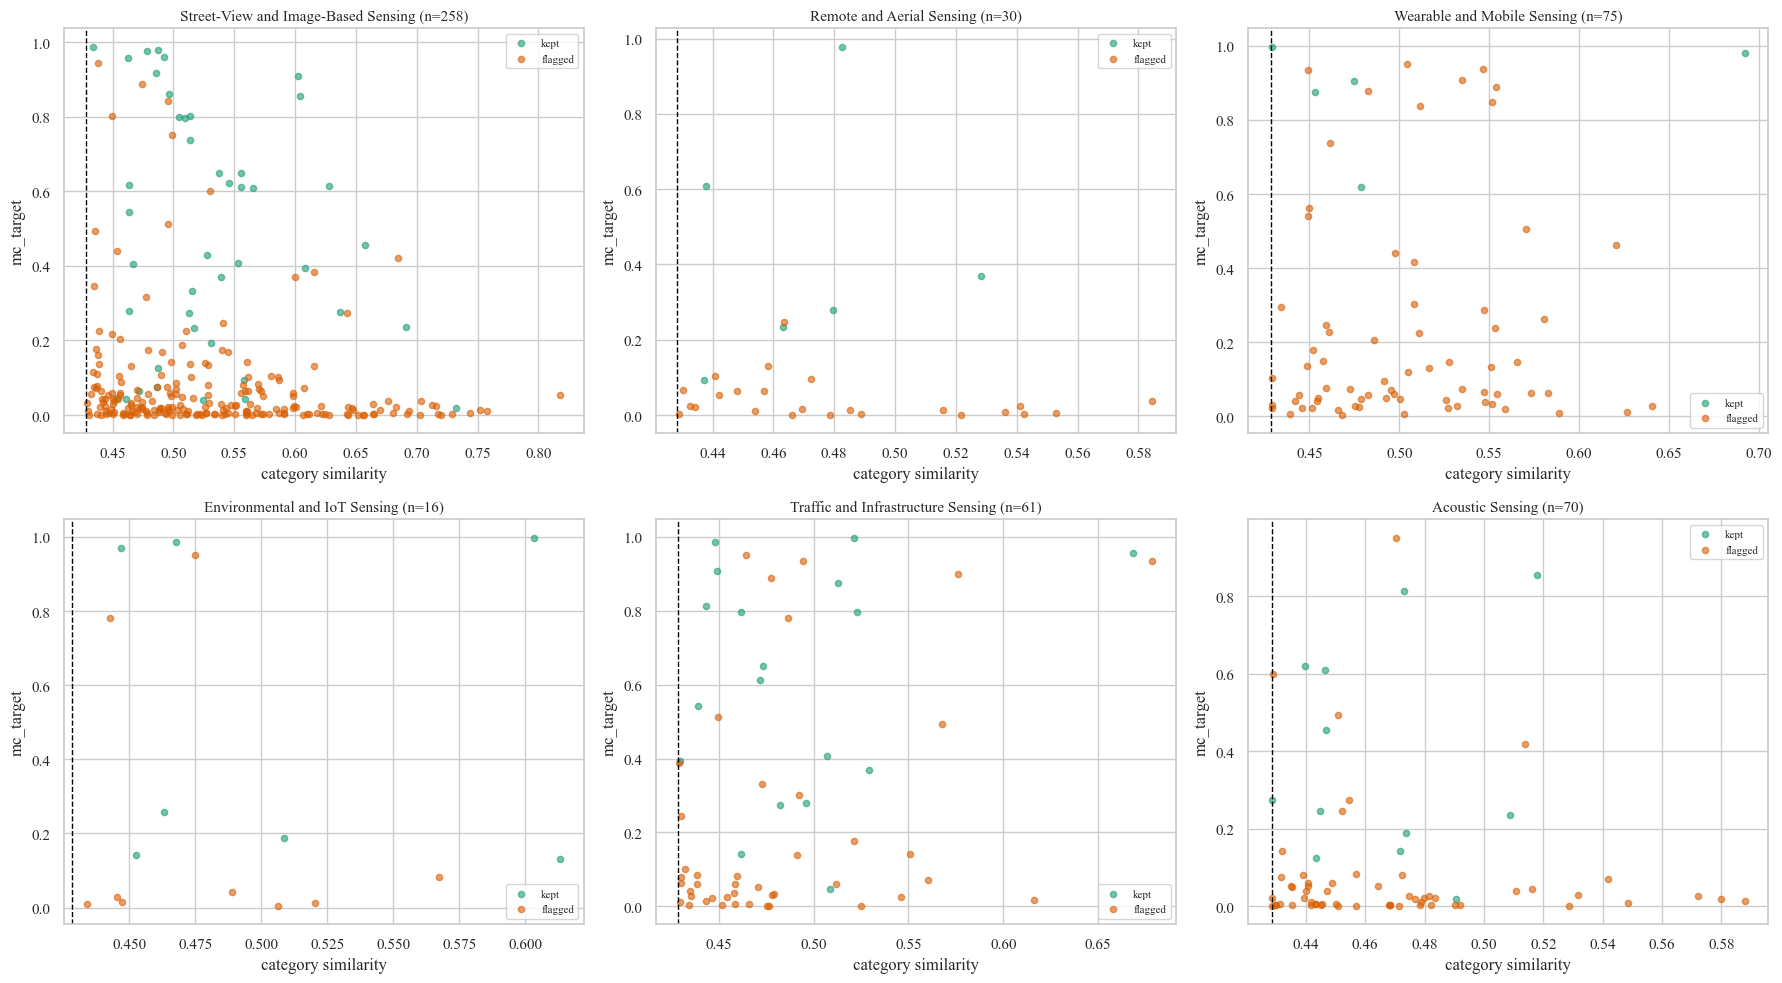

In [7]:
n_categories = len(audit_results)
n_cols = 3
n_rows = int(np.ceil(n_categories / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows), squeeze=False)

for idx, (category, df_cat) in enumerate(audit_results.items()):
    ax = axes[idx // n_cols][idx % n_cols]
    for flagged_value, label, color in [(False, "kept", "#1b9e77"), (True, "flagged", "#d95f02")]:
        subset = df_cat[df_cat["flagged"] == flagged_value]
        ax.scatter(subset["category_similarity"], subset["mc_target"], alpha=0.6, s=20,
                   color=color, label=label)
    ax.axvline(SENSOR_THRESHOLD_FROM_06_2, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{category} (n={len(df_cat)})", fontsize=11)
    ax.set_xlabel("category similarity")
    ax.set_ylabel("mc_target")
    ax.legend(fontsize=8)

for idx in range(n_categories, n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].axis("off")

plt.tight_layout()
plt.show()

# 8. Save the Audited Corpus

Removes the sensor-category label (not the article) wherever a category was flagged
for that article, across all six categories at once.

In [8]:
all_scores = pd.concat(audit_results.values(), ignore_index=True)
all_scores.to_json("../data/06_5_all_categories_audit_scores.json", orient="records", indent=4)

flagged_pairs = set()
for category, df_cat in audit_results.items():
    for doi in df_cat.loc[df_cat["flagged"], "doi"]:
        flagged_pairs.add((doi, category))

def remove_flagged_categories(row):
    return [cat for cat in row["macro_sensor_types"] if (row["doi"], cat) not in flagged_pairs]

df_audited = df.copy()
df_audited["macro_sensor_types"] = df_audited.apply(remove_flagged_categories, axis=1)
df_audited.to_json("../data/06_6_dimensions_with_sensor_types_audited.json", orient="records", indent=4)

n_before = int((df["macro_sensor_types"].str.len() > 0).sum())
n_after = int((df_audited["macro_sensor_types"].str.len() > 0).sum())
print(f"Articles with at least one sensor category before audit: {n_before}")
print(f"Articles with at least one sensor category after audit: {n_after}")
print("\nSaved:")
print("  ../data/06_5_all_categories_audit_scores.json")
print("  ../data/06_6_dimensions_with_sensor_types_audited.json")

Articles with at least one sensor category before audit: 357
Articles with at least one sensor category after audit: 56

Saved:
  ../data/06_5_all_categories_audit_scores.json
  ../data/06_6_dimensions_with_sensor_types_audited.json
